# DICOM Concepts

**DICOM** stands for **Digital Imaging and Communications in Medicine**. It is the international standard for creating, storing, transmitting, and viewing medical images and related health information.

Developed jointly by the American College of Radiology (ACR) and the National Electrical Manufacturers Association (NEMA), DICOM ensures that medical images from different manufacturers (like Siemens, GE, or Philips) can be shared and opened seamlessly across various hospital systems.

---

### Key Features of DICOM

* **Unified File Format (`.dcm`)**: Unlike a standard JPEG or PNG image, a DICOM file bundles the image pixels together with a rich embedded data header.
* **Comprehensive Metadata**: The header contains critical patient information (name, ID, date of birth), study details (date, hospital, ordering physician), and technical acquisition parameters (scanner settings, slice thickness, patient orientation).
* **Network Protocol**: DICOM is also a communication protocol that allows machines (such as an MRI scanner, a PACS archive server, and a doctor's workstation) to talk to each other securely over a network.

### Dicom file

A DICOM file is structured like a dictionary containing two main parts: metadata (patient information, scanner parameters, image dimensions) and pixel data (the actual image).

In [1]:
!pip install pydicom


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


File 'sample_ct.dcm' already exists locally. Skipping download.
Patient Name: CompressedSamples^CT1
Modality: CT


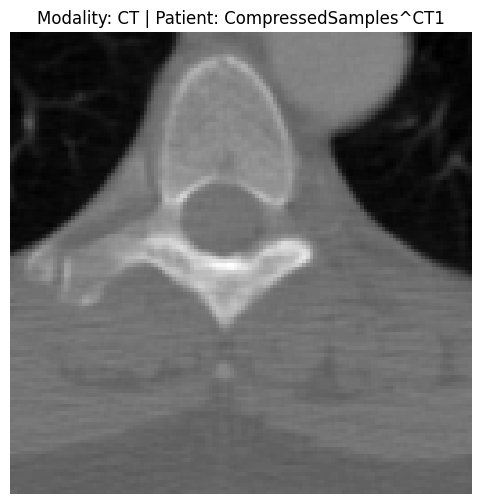

In [2]:
import os
import urllib.request
import pydicom
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/pydicom/pydicom/main/src/pydicom/data/test_files/CT_small.dcm"
file_path = "sample_ct.dcm"

# 1. Check if the file already exists locally
if not os.path.exists(file_path):
    print("File not found locally. Downloading public DICOM image...")
    urllib.request.urlretrieve(url, file_path)
    print(f"Download complete: saved as '{file_path}'")
else:
    print(f"File '{file_path}' already exists locally. Skipping download.")

# 2. Read the file and parse metadata
# a custom class wrapping a dictionary is a good description of pydicom.Dataset
dataset = pydicom.dcmread(file_path)
print(f"Patient Name: {dataset.get('PatientName', 'N/A')}")
print(f"Modality: {dataset.get('Modality', 'N/A')}")

# 3. Extract raw pixel data as a NumPy array
image_array = dataset.pixel_array

# 4. Visualize the image
plt.figure(figsize=(6, 6))
plt.imshow(image_array, cmap="gray")
plt.title(f"Modality: {dataset.get('Modality')} | Patient: {dataset.get('PatientName')}")
plt.axis("off")
plt.show()

# Lazy Header-Only Parsing 
## (stop_before_pixels=True): 

* Inspecting metadata headers  without loading heavy pixel arrays,
* This optimizes initial scan discovery speed, while scanning across an entire series of Dicom images

In [3]:
file_path = "sample_ct.dcm"

if os.path.exists(file_path):
    # READ THE META DATA ONLY, NOT THE IMAGE
    dataset = pydicom.dcmread(file_path, stop_before_pixels="True")
    for elem in  list(dataset)[:10]:
        print(f"{elem.keyword}, {elem.tag} : {elem.value}")

SpecificCharacterSet, (0008,0005) : ISO_IR 100
ImageType, (0008,0008) : ['ORIGINAL', 'PRIMARY', 'AXIAL']
InstanceCreationDate, (0008,0012) : 20040119
InstanceCreationTime, (0008,0013) : 072731
InstanceCreatorUID, (0008,0014) : 1.3.6.1.4.1.5962.3
SOPClassUID, (0008,0016) : 1.2.840.10008.5.1.4.1.1.2
SOPInstanceUID, (0008,0018) : 1.3.6.1.4.1.5962.1.1.1.1.1.20040119072730.12322
StudyDate, (0008,0020) : 20040119
SeriesDate, (0008,0021) : 19970430
AcquisitionDate, (0008,0022) : 19970430


# Background Pixel Padding Masking 
## (PixelPaddingValue & PixelPaddingRangeLimit)

In medical imaging, scanners often pad the edges of the image matrix with a constant pixel value (representing background air, the scanner bed, or outside borders) to keep dimensions uniform.

### Pixel Padding Masking 

uses specific DICOM metadata tags to identify and exclude these non-tissue background pixels so they don't interfere with analysis, visualization, or machine learning models.

padding_value:  -2000 , padding_limit:  None
alt_padding_value:  -2000
Found PixelPaddingValue: -2000


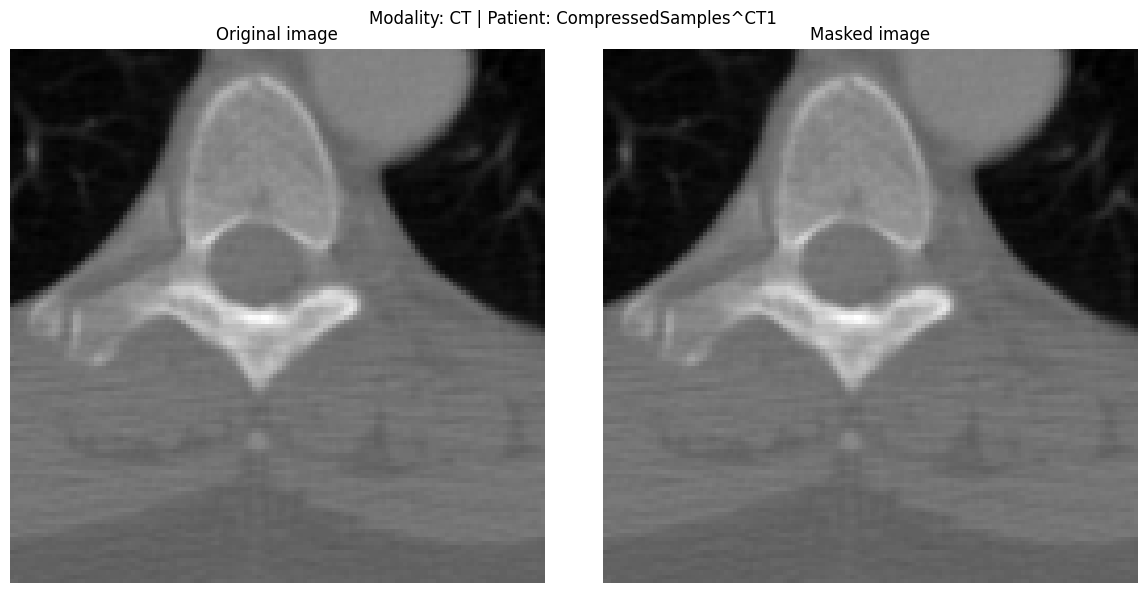

In [6]:
import numpy as np

# Load dataset with pixel data
# a custom class wrapping a dictionary is a good description of pydicom.Dataset
dataset = pydicom.dcmread("sample_ct.dcm")
image_array = dataset.pixel_array

# Check for padding tags
padding_value = dataset.get("PixelPaddingValue", None)
padding_limit = dataset.get("PixelPaddingRangeLimit", None)

print("padding_value: ", padding_value, 
      ", padding_limit: ", padding_limit)
alt_padding_value = dataset[0x0028, 0x0120].value
print("alt_padding_value: ", alt_padding_value)

if padding_value is not None:
    print(f"Found PixelPaddingValue: {padding_value}")
    
    # Create a boolean mask to exclude padding pixels
    if padding_limit is not None:
        # Mask out a range of values
        mask = ~((image_array >= padding_value) & (image_array <= padding_limit))
    else:
        # Mask out a single specific padding value
        mask = (image_array != padding_value)

    cleaned_image = np.where(mask, image_array, 0)

else:
    print("No PixelPaddingValue found; the masked image is unchanged.")
    cleaned_image = image_array.copy()

# Compare both images using the same grayscale intensity range.
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
vmin, vmax = image_array.min(), image_array.max()
for ax, image, title in zip(
    axes,
    (image_array, cleaned_image),
    ("Original image", "Masked image"),
):
    ax.imshow(image, cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")

fig.suptitle(f"Modality: {dataset.get('Modality')} | Patient: {dataset.get('PatientName')}")
plt.tight_layout()
plt.show()


# Modality Look-Up Table Calibration

Storage & Transmission: Storing pixels as compact 16-bit integers cuts file sizes and memory usage in half compared to 32-bit floating-point numbers. It also makes lossless compression algorithms work much more efficiently.

Accuracy & Physics: When you need to do clinical measurements or analysis, you apply the slope and intercept on the fly in memory. This instantly transforms those efficient integers back into precise physical units (like exact Hounsfield Units) without wasting gigabytes of disk space across hospital archives.

For a standard DICOM image (or a single slice of a scan), there is typically one global slope and one global intercept stored in the header that applies uniformly to every single pixel in that array.

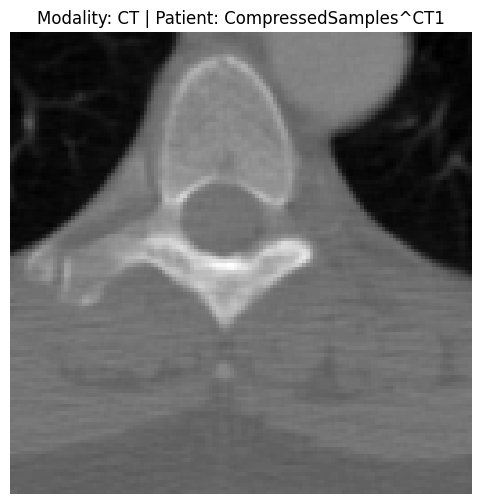

In [7]:
import pydicom
import numpy as np

# Load dataset and pixel array
dataset = pydicom.dcmread("sample_ct.dcm")
image_array = dataset.pixel_array

# Retrieve slope and intercept (default to 1 and 0 if not present)
slope = getattr(dataset, "RescaleSlope", 1)
intercept = getattr(dataset, "RescaleIntercept", 0)

# Convert raw integers to physical units
calibrated_image = image_array * slope + intercept

plt.figure(figsize=(6, 6))
plt.imshow(calibrated_image, cmap="gray")
plt.title(f"Modality: {dataset.get('Modality')} | Patient: {dataset.get('PatientName')}")
plt.axis("off")
plt.show()

### Use the built in function (apply_modality_lut):

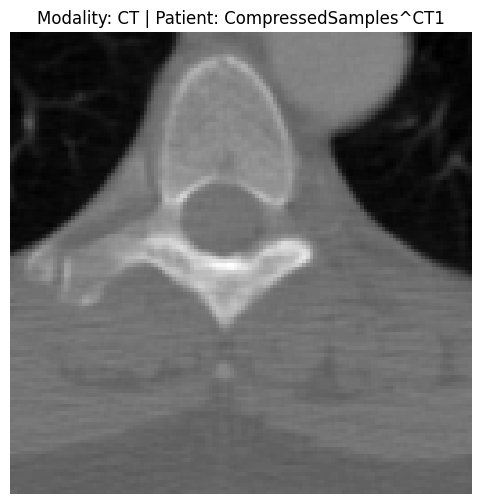

In [9]:
from pydicom.pixel_data_handlers.util import apply_modality_lut
# 2. Let pydicom handle the calibration safely
calibrated_image = apply_modality_lut(image_array, dataset)

plt.figure(figsize=(6, 6))
plt.imshow(calibrated_image, cmap="gray")
plt.title(f"Modality: {dataset.get('Modality')} | Patient: {dataset.get('PatientName')}")
plt.axis("off")
plt.show()

## Correcting luminance conventions (MONOCHROME1 vs MONOCHROME2)

Different manufacturers or modalities handle luminance differently, DICOM files generally use one of two main grayscale conventions: MONOCHROME2 or MONOCHROME1.

* MONOCHROME2 (Standard View):

  * Minimum pixel value = Black (0)

  * Maximum pixel value = White

* MONOCHROME1 (Inverted View):

  * Minimum pixel value = White

  * Maximum pixel value = Black (0)
 
To ensure consistent training signals, pipelines typically inspect the photometric tag and invert MONOCHROME1 images so that all inputs share a uniform scale.


Original Photometric Interpretation: MONOCHROME2
Original min/max: 128 / 2191
Inverted min/max: 30576 / 32639


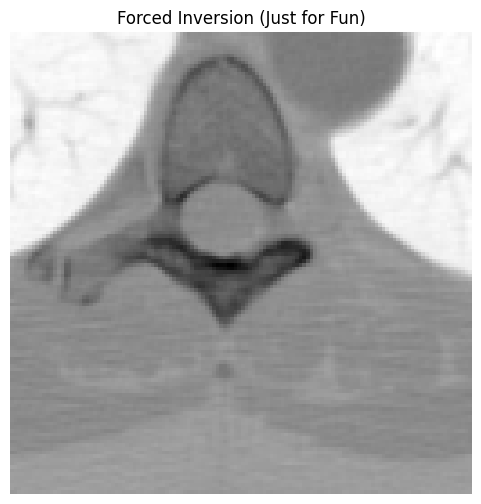

In [11]:
import pydicom
import numpy as np
import matplotlib.pyplot as plt

# 1. Load dataset and pixel array
dataset = pydicom.dcmread("sample_ct.dcm")
image_array = dataset.pixel_array
photometric = dataset.get("PhotometricInterpretation", "MONOCHROME2")

print(f"Original Photometric Interpretation: {photometric}")
print(f"Original min/max: {image_array.min()} / {image_array.max()}")

# 2. Invert regardless of convention ("just for fun")
# For integer arrays, subtract from the max possible value of that dtype
max_val = np.iinfo(image_array.dtype).max
inverted_image = max_val - image_array

print(f"Inverted min/max: {inverted_image.min()} / {inverted_image.max()}")

# 3. Visualize the fully inverted image
plt.figure(figsize=(6, 6))
plt.imshow(inverted_image, cmap="gray")
plt.title("Forced Inversion (Just for Fun)")
plt.axis("off")
plt.show()

## DICOM Provenance & SOP Tracking

* DICOM Provenance & SOP Tracking is the practice of maintaining a strict, verifiable digital audit trail for every medical image.
    * SOP Instance UID (0008, 0018): Stands for Service-Object Pair Instance Unique Identifier. This is a globally unique number generated for every single DICOM object (like an individual slice or report). No two images in the world should ever share the same SOP Instance UID. It ensures that if a file is copied, moved, or processed, you can always trace it back to its exact origin.

    * Transfer Syntax UID (0002, 0010): Tells you how the data bytes inside the file are packaged and compressed (e.g., Little Endian vs. Big Endian, Explicit vs. Implicit VR, or whether it uses a compression algorithm like JPEG Lossless). Knowing the transfer syntax is mandatory so your software knows how to correctly decode the pixel data without introducing corruption.

In [12]:
import pydicom

# Load dataset (including file meta information where transfer syntax lives)
dataset = pydicom.dcmread("sample_ct.dcm")

# Extract unique identifiers and encoding info
sop_instance_uid = dataset.get("SOPInstanceUID", "Unknown")
sop_class_uid = dataset.get("SOPClassUID", "Unknown")
transfer_syntax = dataset.file_meta.get("TransferSyntaxUID", "Unknown")

print("--- DICOM Provenance & Traceability ---")
print(f"SOP Class UID (What kind of object it is): {sop_class_uid}")
print(f"SOP Instance UID (The global digital fingerprint): {sop_instance_uid}")
print(f"Transfer Syntax UID (How it is encoded/compressed): {transfer_syntax}")

--- DICOM Provenance & Traceability ---
SOP Class UID (What kind of object it is): 1.2.840.10008.5.1.4.1.1.2
SOP Instance UID (The global digital fingerprint): 1.3.6.1.4.1.5962.1.1.1.1.1.20040119072730.12322
Transfer Syntax UID (How it is encoded/compressed): 1.2.840.10008.1.2.1
